## Script to process a single year's summer stats relative to the baseline and produce global map and zonal plot of summer length

In [4]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from cartopy import crs as ccrs, feature as cfeature
import netCDF4
from netCDF4 import Dataset
from datetime import datetime as dt

# helper functions

# a function that takes in the data for a specific lat/lon and returns the start/end,length of summer
# and generates a plot if requested
def SummerStats(temp_data, threshold, save_plot):
    '''

    Function that uses the input 75th percentile temperature in K to identify the summer from a time series of temperatures

    Args:
        temp_data: xarray of temperature data for a single grid cell
        threshold: xarray for the 75th percentile threshold to use
        save_plot: save out a png of the time series with threshold, summer start/end shown
        
    Returns:
        start day, end day, summer length
        
    Example:
        start_day, last_day, summer_length = SummerStats(input_temps, input_thresh, True)

    '''
    # extract DOY and T2m values for those days
    x1 = temp_data.time.dt.dayofyear.values
    y1 = temp_data.values

    #print(x1, y1)
    # polynomial fit, degree 3 as in Wang et al 2021
    coefs = np.polyfit(x1, y1, 3)
    poly = np.poly1d(coefs)

    ## *** TO-DO *** x_values needs to deal with leap years if not already handled
    x_values = np.linspace(min(x1), max(x1), 366) # create some x values for plotting polynomial fit

    # use fit to get stats
    # this summer_length works for NH and will require adjustment for SH
    summer_length = np.count_nonzero(poly(x_values) >= threshold.values)
    summer_days = np.where(poly(x_values) >= threshold.values)[0]
    # in SH we end the prev year when going below and start the current year when going above
    not_summer_days = np.where(poly(x_values) < threshold.values)[0]

    # deal with grids that didn't have days above threshold
    if summer_length == 0:
        first_day = 0
        last_day = 0
    else: 
        if temp_data.lat.values >= 0:
            # Northern Hemisphere
            first_day = x_values[min(summer_days)]
            last_day = x_values[max(summer_days)]
        else:
            # Southern Hemisphere - last day is really the last day of prior year
            # and first day is really the first day of current year
            # but I will write separate script to make adjustments to start/end/length
            if np.count_nonzero(not_summer_days) <= 0: 
                # this means we are in the SH but temps are always above threshold so summer is 365 days long
                # essentially the logic is same as for NH then except start/end might get wonky
                # this case is likely in the tropics
                first_day = x_values[min(summer_days)]
                last_day = x_values[max(summer_days)]
            else:
                # we are in the SH but summer is not all year long
                first_day = x_values[max(not_summer_days)]
                last_day = x_values[min(not_summer_days)]
                summer_length = 365.0 - np.count_nonzero(not_summer_days)

    # make and save plot if desired
    ##
    ##
    if save_plot:
        cell_lat = temp_data.lat.values
        cell_lon = temp_data.lon.values
        yr = temp_data.time.dt.year.values[0]

        plt.figure(figsize=(16,6))
        plt.plot(x1,y1, label='daily mean T2m')
        plt.plot(x_values, poly(x_values), label='fitted degree 3 polynomial', color='red')
        plt.axhline(threshold.values, color="black", linewidth=0.8, linestyle="dashed") 
        plt.axvline(first_day, color="black", linewidth=0.8, linestyle="dashed")
        plt.axvline(last_day, color="black", linewidth=0.8, linestyle="dashed")
        plt.annotate('start', xy=(first_day-5,np.max(poly(x_values))+2), fontsize=12)
        plt.annotate('end', xy=(last_day-5,np.max(poly(x_values))+2), fontsize=12)
        plt.annotate('summer = '+str(summer_length)+' days', xy=(first_day+5,np.mean(poly(x_values))), fontsize=18)
        plt.annotate('75th percentile = '+str(np.round(threshold.values,1))+'K', xy=(0,threshold.values+1), fontsize=18)
        plt.xlabel('DOY (' + str(yr) + ')')
        plt.ylabel('Mean Daily Temp (K)')
        plt.title(str(yr) + " Summer for Lat,Lon = [" +str(cell_lat)+","+str(cell_lon)+ "] Baseline Years = (check data)")
        plt.legend()
        plt.savefig("polyfit_stats_"+str(cell_lat)+"_"+str(cell_lon)+"_"+str(yr)+".png")
        plt.show()

    # return
    return first_day, last_day, summer_length


# a function that takes in a dataset of global t2m values and if it is a leap year averages
# the temps on Feb 28 & Feb 29, then drops Feb 29 to ensure the year has 365 days
def HandleLeapYears(input_ds):
    '''

    Function that takes the mean of Feb 28 & Feb 29 (if it exists) and returns an xarray Dataset that has 365 days
    where Feb 28 will now have a t2m value that is the mean of Feb 28 & Feb 29

    Args:
        input_ds: the data set containing a single year of data that may need adjusting for leap year
        
    Returns:
        output_ds
        
    Example:
        no_leap_ds = HandleLeapYears(input_ds)

    '''
    

    # check if a leap year
    if(input_ds.time.dt.is_leap_year[0].values):
        
        # make deep copy
        output_ds = input_ds.copy(deep=True)
        
        # get mean of Feb 28 (time index 58) & Feb 29 (time index 59) for each grid cell and overwrite Feb 28 with it
        mean_dat = output_ds.t2m[58:60].mean(dim='time', skipna=True, keep_attrs=True)
        output_ds.t2m[58] = mean_dat
        
        # drop Feb 29
        output_ds = output_ds.convert_calendar('noleap')

        # return the new dataset 
        return output_ds
    else:
        return input_ds
    

### Grab the threshold temps

In [5]:
file_path = '../../../Data/ERA5-global/Baseline/computed_1960-1990-every5_75th.nc'
c_75 = xr.open_dataarray(file_path)
c_75.values

array([[235.96458435, 235.96458435, 235.96458435, ..., 235.96458435,
        235.96458435, 235.96458435],
       [235.79866409, 235.80046844, 235.80244827, ..., 235.79285812,
        235.79487228, 235.79656982],
       [235.53240585, 235.53595352, 235.53955078, ..., 235.52448273,
        235.52680969, 235.52918625],
       ...,
       [271.25493622, 271.25526428, 271.25531769, ..., 271.25588989,
        271.25550842, 271.25489807],
       [271.23865509, 271.23862457, 271.23828888, ..., 271.23796082,
        271.23818207, 271.2384491 ],
       [271.1616745 , 271.1616745 , 271.1616745 , ..., 271.1616745 ,
        271.1616745 , 271.1616745 ]])

### Grab desired year of data and process it. The below sequence of cells should be turned into a loop for processing multiple years!

In [42]:
### input year
input_year = str(2023)
print(input_year)

2023


In [43]:
# 
file_path = '../../../Data/ERA5-global/Analysis/' + input_year + '/*.nc'
ds = xr.open_mfdataset(file_path)
ds

<xarray.Dataset> Size: 2GB
Dimensions:      (time: 365, lat: 721, lon: 1440)
Coordinates:
  * time         (time) datetime64[ns] 3kB 2023-01-01 2023-01-02 ... 2023-12-31
    realization  int64 8B 0
  * lat          (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * lon          (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
Data variables:
    t2m          (time, lat, lon) float32 2GB dask.array<chunksize=(31, 721, 1440), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.7
    institution:  European Centre for Medium-Range Weather Forecasts
    history:      2024-06-12T22:52 GRIB to CDM+CF via cfgrib-0.9.9.1/ecCodes-...
    source:       ECMWF

### Deal with any leap days using helper to reduce all years to 365 days by averaging Feb 28 & 29 into Feb 28 then dropping Feb 29

In [4]:
#help(HandleLeapYears)

In [44]:
ds = HandleLeapYears(ds)
ds.load() # have to do this to speed up the summer stats processing
ds

<xarray.Dataset> Size: 2GB
Dimensions:      (time: 365, lat: 721, lon: 1440)
Coordinates:
  * time         (time) datetime64[ns] 3kB 2023-01-01 2023-01-02 ... 2023-12-31
    realization  int64 8B 0
  * lat          (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * lon          (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
Data variables:
    t2m          (time, lat, lon) float32 2GB 248.4 248.4 248.4 ... 246.1 246.1
Attributes:
    Conventions:  CF-1.7
    institution:  European Centre for Medium-Range Weather Forecasts
    history:      2024-06-12T22:52 GRIB to CDM+CF via cfgrib-0.9.9.1/ecCodes-...
    source:       ECMWF

### Process the year to find summer length, start, and end days. Save dataset and plots.

In [45]:
# set up data arrays and grid cells to loop over

num_lat = 721
num_lon = 1440

loop_lats = c_75.lat.values[:num_lat]
loop_lons = c_75.lon.values[:num_lon]


# empty data arrays for summer stats

summerlength = xr.DataArray(np.zeros((num_lat,num_lon)), 
                            coords=[loop_lats, loop_lons], 
                            dims=['lat','lon'])
summerstart = xr.DataArray(np.zeros((num_lat,num_lon)), 
                           coords=[loop_lats, loop_lons], 
                           dims=['lat','lon'])
summerend = xr.DataArray(np.zeros((num_lat,num_lon)), 
                         coords=[loop_lats, loop_lons], 
                         dims=['lat','lon'])

# add attributes
summerstart.attrs["long_name"] = "Start day of summer for the year (DOY in [1,365])"
summerstart.attrs["units"] = "Day of year"

summerend.attrs["long_name"] = "Last day of summer for the year (DOY in [1,365])"
summerend.attrs["units"] = "Day of year"

summerlength.attrs["long_name"] = "Duration of summer for the year"
summerlength.attrs["units"] = "Days"
#summerlength

In [46]:
%%time

# for printing every X grids
counter = 1

# loop through all of the lat,lon of interest
for input_lat in loop_lats:
    for input_lon in loop_lons:

        # get threshold from c_75
        thresh = c_75.sel(lat=input_lat,lon=input_lon)

        # all the temps for that grid cell over time
        temps = ds.t2m.sel(lat=input_lat,lon=input_lon) # this is a single year's dataset right now

        # build summer stats for the grid cell and produce the plot if desired
        start_day, last_day, summer_length = SummerStats(temps, thresh, False)
        
        # xarray requires strange indexing in order to replace values by coordinate
        summerstart.loc[input_lat, input_lon] = start_day
        summerend.loc[input_lat, input_lon] = last_day
        summerlength.loc[input_lat, input_lon] = summer_length

        counter +=1


CPU times: user 9min 30s, sys: 565 ms, total: 9min 31s
Wall time: 9min 32s


In [47]:
sum_ds = xr.Dataset(data_vars={'SummerStart':summerstart,
                                   'SummerEnd':summerend,
                                   'SummerLength':summerlength})
sum_ds

<xarray.Dataset> Size: 25MB
Dimensions:       (lat: 721, lon: 1440)
Coordinates:
  * lat           (lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * lon           (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
Data variables:
    SummerStart   (lat, lon) float64 8MB 319.1 319.1 319.1 319.1 ... 0.0 0.0 0.0
    SummerEnd     (lat, lon) float64 8MB 36.9 36.9 36.9 36.9 ... 0.0 0.0 0.0 0.0
    SummerLength  (lat, lon) float64 8MB 81.0 81.0 81.0 81.0 ... 0.0 0.0 0.0 0.0

In [48]:
# output results to file
output_path = '../../../Data/ERA5-global/Analysis/Temp/'+input_year+'_summer_stats.nc'
sum_ds.to_netcdf(output_path)

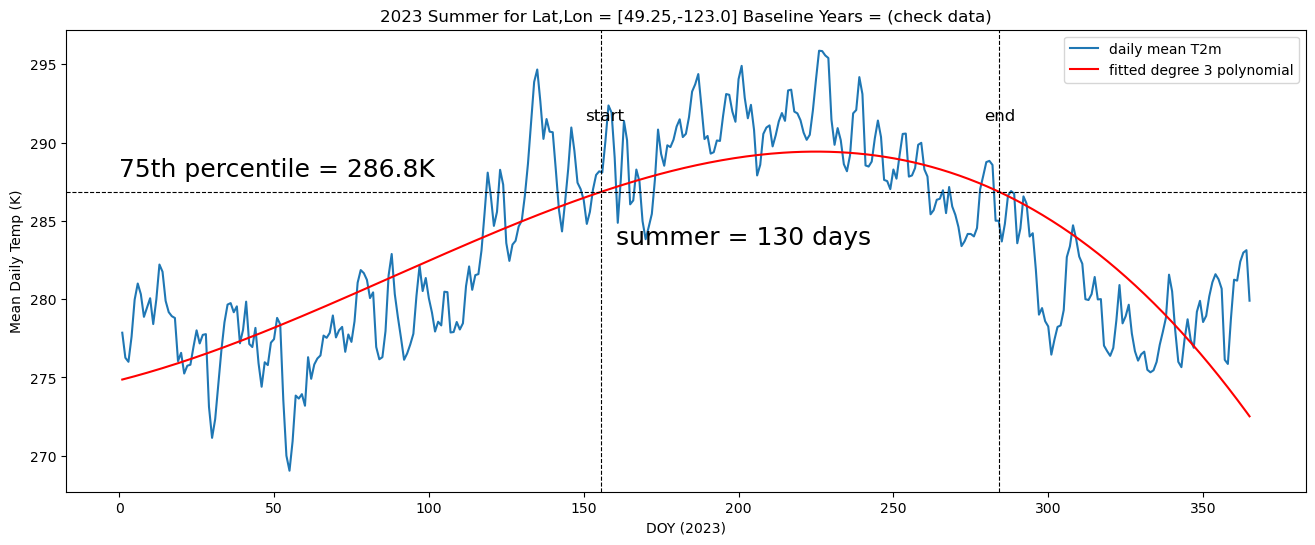

In [49]:
# make plot for Vancouver

input_lat = 49.246
input_lon = -123.116
input_thresh = c_75.sel(lat=input_lat,lon=input_lon, method="nearest")
input_temps = ds.t2m.sel(lat=input_lat,lon=input_lon, method="nearest") # Vancouver is 49.246292, -123.116226

start_day, last_day, summer_length = SummerStats(input_temps, input_thresh, True)

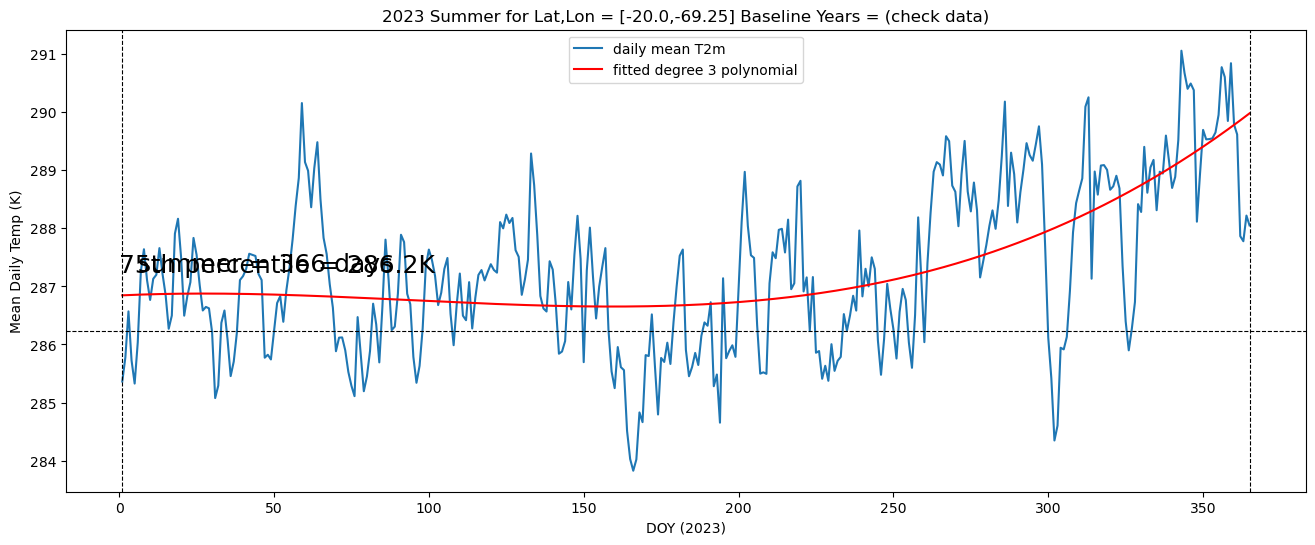

In [50]:
# also test the tropics site lat: -20.0, lon: -69.25 (in Bolivia) 
# and was caught as an issue in the earlier version of SummerLength()


input_lat = -20
input_lon = -69.25
input_thresh = c_75.sel(lat=input_lat,lon=input_lon, method="nearest")
input_temps = ds.t2m.sel(lat=input_lat,lon=input_lon, method="nearest") # Vancouver is 49.246292, -123.116226

start_day, last_day, summer_length = SummerStats(input_temps, input_thresh, True)

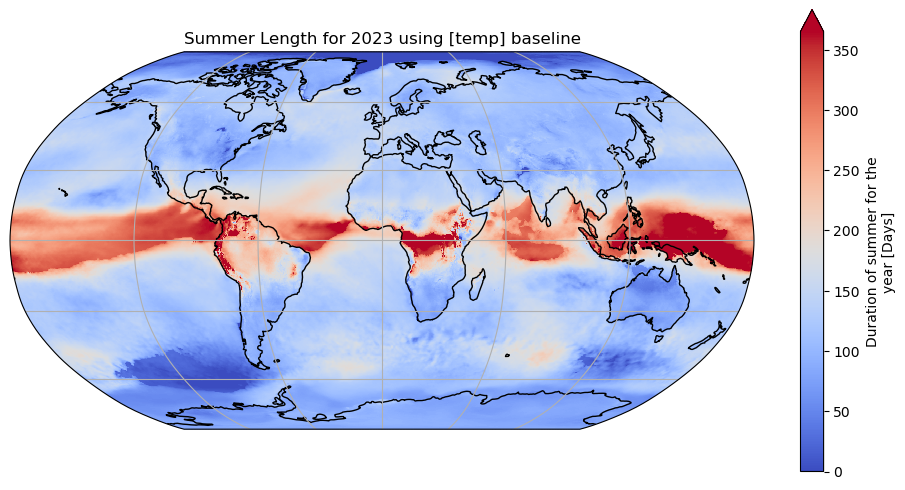

In [51]:
# global summer length for the year
# put some coastlines on there
fig = plt.figure(figsize=(12,6))

# assign axis and def projection to use
ax = plt.axes(projection=ccrs.Robinson(central_longitude=0))

# add coastlines and grid
ax.coastlines()
ax.gridlines()

sum_ds.SummerLength.plot(
    ax=ax,
    transform=ccrs.PlateCarree(), # assign map projection
    vmin=0,
    vmax=365, # define range to include an entire year
    cmap="coolwarm"#"YlOrRd"#cmap="coolwarm"
)

plt.title("Summer Length for "+input_year+" using [temp] baseline")
plt.savefig(input_year+"_SummerLength_global.png")
plt.show()

### add zonal plot of summer length

<>:11: SyntaxWarning: invalid escape sequence '\c'
<>:11: SyntaxWarning: invalid escape sequence '\c'
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_6822/1774243635.py:11: SyntaxWarning: invalid escape sequence '\c'
  ax1.set_ylabel("Latitude ($^\circ$)")


Text(0.5, 1.0, '2023 Summer length by latitude (days)')

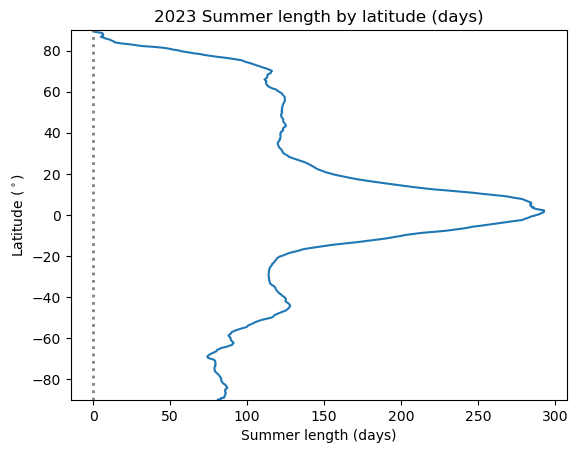

In [52]:
# get mean across all longitudes
zonal_mean = sum_ds.SummerLength.mean(dim="lon")
latitude = sum_ds.lat

# Make a zonal mean figure of the changes
fig, ax1 = plt.subplots(1, 1)
ax1.plot(zonal_mean, latitude)
ax1.axvline(x=0, color="gray", alpha=1, linestyle=":", linewidth=2)
ax1.set_ylim(-90, 90)
ax1.set_xlabel("Summer length (days)")
ax1.set_ylabel("Latitude ($^\circ$)")
ax1.set_title(
    input_year + " Summer length by latitude (days)",  
    loc="center",
)

In [53]:
# close the raw data for 2020 since done with it
ds.close()